# Análise

In [22]:
#Importando bibliotecas necessárias
import pandas as pd
import numpy as np
import warnings
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

# Configurações para exibição de dados
warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:.2f}'.format)
pd.set_option('display.expand_frame_repr', False)
pd.set_option('display.max_columns', None)

caminho_df_limpo = r'C:\Users\lilia\OneDrive\Ambiente de Trabalho\Miniprojeto - Módulo 1\data\dados_limpos.csv'
df_limpo = pd.read_csv(caminho_df_limpo)

print(df_limpo.head(10))

         data     data_br  id_compra  id_cliente  cl_genero cl_estado_civil  num_filhos cl_classe  id_produto cat_produto          nome_produto
0  2019-02-01  01/02/2019       1000         534  MASCULINO           VIUVO           1         C          67     BEBIDAS  REFRIGERANTE GUARANA
1  2019-02-01  01/02/2019       1000         534  MASCULINO           VIUVO           1         C          70     BEBIDAS   REFRIGERANTE OUTROS
2  2019-02-01  01/02/2019       1000         534  MASCULINO           VIUVO           1         C         178     HIGIENE       LENCO UMEDECIDO
3  2019-02-01  01/02/2019       1000         534  MASCULINO           VIUVO           1         C           4   ALIMENTOS               ABACAXI
4  2019-02-01  01/02/2019       1000         534  MASCULINO           VIUVO           1         C         175     LIMPEZA     LIMPADOR MULTIUSO
5  2019-02-01  01/02/2019       1000         534  MASCULINO           VIUVO           1         C         187     HIGIENE      HASTES FL

In [23]:
df_limpo.info()

<class 'pandas.DataFrame'>
RangeIndex: 730219 entries, 0 to 730218
Data columns (total 11 columns):
 #   Column           Non-Null Count   Dtype
---  ------           --------------   -----
 0   data             730219 non-null  str  
 1   data_br          730219 non-null  str  
 2   id_compra        730219 non-null  int64
 3   id_cliente       730219 non-null  int64
 4   cl_genero        730219 non-null  str  
 5   cl_estado_civil  730219 non-null  str  
 6   num_filhos       730219 non-null  int64
 7   cl_classe        730219 non-null  str  
 8   id_produto       730219 non-null  int64
 9   cat_produto      730219 non-null  str  
 10  nome_produto     730219 non-null  str  
dtypes: int64(4), str(7)
memory usage: 61.3 MB


In [24]:
#Importando o csv de forma nativa

import csv

with open('../data/dados_raw.csv', mode='r', encoding='utf-8-sig') as arquivo:
    dados = list(csv.DictReader(arquivo))

print(dados[:3])

#Não vou utilizar este formato. Permanecerei com o Pandas. Aqui, "arquivo" e "dados" não serão chamados de novo.

[{'DATA;CO_ID;CL_ID;CL_GENERO;CL_EC;CL_FHL;CL_SEG;PR_ID;PR_CAT;PR_NOME;;;;': '01/02/2019;1000;534;M;4;1;C;67;BEBIDAS;REFRIGERANTE GUARANA;;;;'}, {'DATA;CO_ID;CL_ID;CL_GENERO;CL_EC;CL_FHL;CL_SEG;PR_ID;PR_CAT;PR_NOME;;;;': '01/02/2019;1000;534;M;4;1;C;70;BEBIDAS;REFRIGERANTE OUTROS;;;;'}, {'DATA;CO_ID;CL_ID;CL_GENERO;CL_EC;CL_FHL;CL_SEG;PR_ID;PR_CAT;PR_NOME;;;;': '01/02/2019;1000;534;M;4;1;C;178;HIGIENE;LENCO UMEDECIDO;;;;'}]


### Coluna num_filhos

In [25]:
print(df_limpo['num_filhos'].describe())

#Media: 1.15 filho
#Desvio padrão: 1,42 filho
#Mínimo, 25%, 50%: 0 filho
#75%: 2 filhos
#max: 4 filhos

print("-"*100)
print(f'A mediana da coluna num_filhos é: {df_limpo['num_filhos'].median()}') #0

print('\n' + "-"*100)
print(f'A moda da coluna num_filhos é: {df_limpo['num_filhos'].mode()}') #0

#Há poucas pessoas com uma quantidade maior de filhos

count   730219.00
mean         1.15
std          1.42
min          0.00
25%          0.00
50%          0.00
75%          2.00
max          4.00
Name: num_filhos, dtype: float64
----------------------------------------------------------------------------------------------------
A mediana da coluna num_filhos é: 0.0

----------------------------------------------------------------------------------------------------
A moda da coluna num_filhos é: 0    0
Name: num_filhos, dtype: int64


### Agrupamentos, pivot tables

In [26]:
#Relação número de compras e gênero

df_limpo.groupby('cl_genero')['id_compra'].count()

#Mulheres compraram mais

cl_genero
FEMININO     380735
MASCULINO    349484
Name: id_compra, dtype: int64

In [27]:
#Relação número de filhos e gênero

tabela_genero_filho = pd.crosstab(
    index=df_limpo['cl_genero'], 
    columns='Média de filhos',
    values=df_limpo['num_filhos'],
    aggfunc='mean',
    margins=True,      
    margins_name='Média Geral'
)

print(tabela_genero_filho)

#A média de filhos para os homens é levemente maior que para mulheres

col_0        Média de filhos  Média Geral
cl_genero                                
FEMININO                1.09         1.09
MASCULINO               1.21         1.21
Média Geral             1.15         1.15


In [28]:
#Relação estado civil x gênero

tabela_com_totais = pd.crosstab(
    index=df_limpo['cl_estado_civil'], 
    columns=df_limpo['cl_genero'],
    values=df_limpo['id_compra'],
    margins=True,       
    aggfunc='count',
    margins_name='Total Geral'
)

print(tabela_com_totais)

#A maior fatia está no grupo dos divorciados. Casado, Solteiro e Viuvo apresentam valores muito próximos.

#Calculando as porcentagens:
tabela_porcentagem = pd.crosstab(
    index=df_limpo['cl_estado_civil'], 
    columns=df_limpo['cl_genero'], 
    normalize='index'
) * 100

tabela_porcentagem

#As mulheres só não representam maioria na categoria "outro".

cl_genero        FEMININO  MASCULINO  Total Geral
cl_estado_civil                                  
CASADO              87869      83611       171480
DIVORCIADO         100255      87983       188238
OUTROS              13734       7093        20827
SOLTEIRO            79298      91946       171244
VIUVO               99579      78851       178430
Total Geral        380735     349484       730219


cl_genero,FEMININO,MASCULINO
cl_estado_civil,,
CASADO,51.24,48.76
DIVORCIADO,53.26,46.74
OUTROS,65.94,34.06
SOLTEIRO,46.31,53.69
VIUVO,55.81,44.19


In [29]:
#Relação cat_produto e gênero

pivot = pd.pivot_table(
    df_limpo,
    values='id_compra',              # o que agregar
    index='cat_produto',             # linhas
    columns='cl_genero',    # colunas
    aggfunc='count',           # função de agregação
    fill_value=0                 # substituir NaN por 0
)

print(pivot)

#Saiu um resultado #N/D, mas não existe nenhum dado assim na df_limpa


#Calculando as porcentagens:
tabela_porcentagem = pd.crosstab(
    index=df_limpo['cat_produto'], 
    columns=df_limpo['cl_genero'], 
    normalize='index'
) * 100

tabela_porcentagem

#As mulheres commpram mais produtos de todas as categorias que os homens.

cl_genero    FEMININO  MASCULINO
cat_produto                     
ACESSORIOS       6839       6032
ALIMENTOS      200274     183923
BEBIDAS         19764      18500
HIGIENE         71721      65981
LIMPEZA         67328      61304
PET             14809      13744


cl_genero,FEMININO,MASCULINO
cat_produto,,
ACESSORIOS,53.13,46.87
ALIMENTOS,52.13,47.87
BEBIDAS,51.65,48.35
HIGIENE,52.08,47.92
LIMPEZA,52.34,47.66
PET,51.86,48.14


In [30]:
#Relação cat_produto e estado civil

pivot = pd.pivot_table(
    df_limpo,
    values='id_compra',              # o que agregar
    index='cat_produto',             # linhas
    columns='cl_estado_civil',    # colunas
    aggfunc='count',           # função de agregação
    fill_value=0                 # substituir NaN por 0
)

print(pivot)

#Calculando as porcentagens:
tabela_porcentagem = pd.crosstab(
    index=df_limpo['cat_produto'], 
    columns=df_limpo['cl_estado_civil'], 
    normalize='index',
    margins=True
) * 100

tabela_porcentagem

#Os divorciados compraram mais em relação aos outros estados civis, seguido pelos viuvos.
#A distribuição da compra entre as categorias está equilibrada. Nenhum dado chama a atenção.

cl_estado_civil  CASADO  DIVORCIADO  OUTROS  SOLTEIRO  VIUVO
cat_produto                                                 
ACESSORIOS         3006        3411     346      2993   3115
ALIMENTOS         90379       98817   10986     90143  93872
BEBIDAS            9109        9805    1127      8969   9254
HIGIENE           32172       35615    3858     32287  33770
LIMPEZA           30121       33218    3696     30088  31509
PET                6693        7372     814      6764   6910


cl_estado_civil,CASADO,DIVORCIADO,OUTROS,SOLTEIRO,VIUVO
cat_produto,,,,,
ACESSORIOS,23.35,26.50,2.69,23.25,24.20
ALIMENTOS,23.52,25.72,2.86,23.46,24.43
BEBIDAS,23.81,25.62,2.95,23.44,24.18
HIGIENE,23.36,25.86,2.80,23.45,24.52
LIMPEZA,23.42,25.82,2.87,23.39,24.50
PET,23.44,25.82,2.85,23.69,24.20
All,23.48,25.78,2.85,23.45,24.44


In [36]:
# Garante que a coluna está em formato datetime
df_limpo['data'] = pd.to_datetime(df_limpo['data'])

# 1. Abre a caixinha para o usuário digitar o número da linha
resposta = input("Digite o número da linha que deseja analisar (ex: 0, 1, 4, 7, 555): ")

# 2. Tenta executar a análise (usamos o try/except para o código não quebrar se digitarem texto)
try:
    # Transforma o texto digitado em um número inteiro
    indice = int(resposta)
    
    # Busca a linha específica que o usuário escolheu
    linha = df_limpo.iloc[indice]
    
    # Extrai o mês e o ID da compra daquela linha
    mes_da_compra = linha['data'].month
    id_compra = linha['id_compra']
    
    print("-" * 50)
    print(f"🔍 Analisando a linha {indice} (Compra ID: {id_compra})...")
    print(f"📅 Data da compra: {linha['data'].strftime('%d/%m/%Y')}")
    
    # 3. A nossa estrutura condicional IF / ELSE entra em ação
    if mes_da_compra <= 6:
        print(f"✅ Resultado: Esta transação ocorreu no 1º Semestre (Mês {mes_da_compra}).")
    else:
        print(f"✅ Resultado: Esta transação ocorreu no 2º Semestre (Mês {mes_da_compra}).")
    print("-" * 50)

except ValueError:
    print("❌ Erro: Por favor, digite apenas números inteiros válidos!")
except IndexError:
    print(f"❌ Erro: Essa linha não existe. Escolha um número entre 0 e {len(df_limpo) - 1}.")

--------------------------------------------------
🔍 Analisando a linha 9876 (Compra ID: 13284)...
📅 Data da compra: 29/01/2019
✅ Resultado: Esta transação ocorreu no 1º Semestre (Mês 1).
--------------------------------------------------


# Outliers

Não há nenhuma coluna do df que apresente dados investigáveis para outliers. Seria necessário algo como preço, por exemplo, onde realmente haver um valor muito baixo ou muito alto fizesse sentido. Aqui, muitas colunas representam índices (do cliente, do pedido), muitas representam categorias (nome do produto, categoria, estado civil, classe, etc). 

Para resolver isto, vou fazer um feature engineering e gerar a coluna itens_por_compra.

In [25]:
df_limpo['itens_por_compra'] = df_limpo['id_compra'].map(df_limpo['id_compra'].value_counts())

print(df_limpo['itens_por_compra'].describe())

#A compra mínima foi a que continha 1 item
#A compra máxima foi a que continha 81 itens.
#A média é de 50.94 itens por compra.
#Esses valores não parecem fora de lógica. É possível uma compra ter 1 ou 81 itens.

count   730219.00
mean        50.94
std         17.14
min          1.00
25%         39.00
50%         54.00
75%         65.00
max         81.00
Name: itens_por_compra, dtype: float64


### Método IQR

In [26]:
Q1  = df_limpo['itens_por_compra'].quantile(0.25)   # 25% dos preços estão abaixo daqui
Q3  = df_limpo['itens_por_compra'].quantile(0.75)   # 75% dos preços estão abaixo daqui
IQR = Q3 - Q1                     # a "amplitude" do miolo dos dados

# PASSO 2: Calcular os limites
lim_inf = Q1 - 1.5 * IQR    # abaixo disso = outlier inferior
lim_sup = Q3 + 1.5 * IQR    # acima disso = outlier superior

print(f"Faixa normal: [{lim_inf:.2f}, {lim_sup:.2f}]")

# PASSO 3: Ver quais são os outliers
mascara = (df_limpo['itens_por_compra'] < lim_inf) | (df_limpo['itens_por_compra'] > lim_sup)
print(f"Outliers encontrados: {mascara.sum()}")

compras_outliers = df_limpo[mascara]['id_compra'].nunique()
print(f"Quantidade de carrinhos de compras únicos que são outliers: {compras_outliers}")


Faixa normal: [0.00, 104.00]
Outliers encontrados: 0
Quantidade de carrinhos de compras únicos que são outliers: 0


### Z-score

In [27]:
# Calcular o Z-Score de uma coluna
media  = df_limpo['itens_por_compra'].mean()    # média dos salários
desvio = df_limpo['itens_por_compra'].std()     # desvio padrão

z_scores = (df_limpo['itens_por_compra'] - media) / desvio
# z = 0   → valor igual à média
# z = 2   → 2 desvios ACIMA da média
# z = -3  → 3 desvios ABAIXO = outlier!

# Filtrar quem tem z muito alto ou muito baixo
outliers = df_limpo[z_scores.abs() > 3]
print(f"Outliers (|z| > 3): {len(outliers)}")
print(outliers[['id_compra', 'itens_por_compra']])

Outliers (|z| > 3): 0
Empty DataFrame
Columns: [id_compra, itens_por_compra]
Index: []


### Capping

In [28]:
#df['itens_por_compra'] = df['preco'].clip(
#    lower=Q1 - 1.5*IQR,
#    upper=Q3 + 1.5*IQR
#)

#Não há outliers encontrados pelos outros dois métodos, então não vou aplicar o capping.

# Gráficos

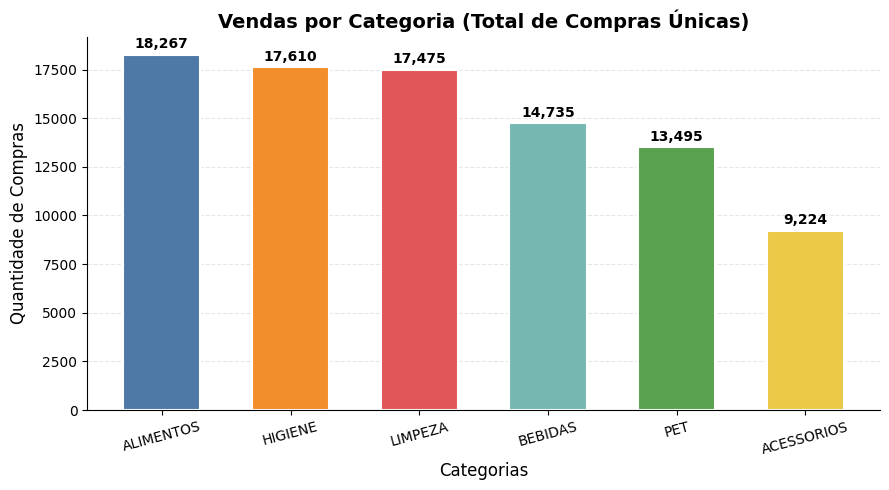

In [29]:
dados_grafico = df_limpo.groupby('cat_produto')['id_compra'].nunique().sort_values(ascending=False)

categorias = dados_grafico.index          # Os nomes das 7 categorias
valores_compras = dados_grafico.values    # As quantidades de vendas de cada uma
cores = ['#4e79a7', '#f28e2b', '#e15759', '#76b7b2', '#59a14f', '#edc948', '#b07aa1']

fig, ax = plt.subplots(figsize=(9, 5))

barras = ax.bar(categorias, 
                valores_compras,   
                color=cores, 
                width=0.6, 
                edgecolor='white', 
                linewidth=1.5)

for barra in barras:
    altura = barra.get_height()  
    ax.text(
        barra.get_x() + barra.get_width() / 2,  
        altura + (valores_compras.max() * 0.01), 
        f'{altura:,.0f}',                      
        ha='center',  
        va='bottom',  
        fontsize=10,
        fontweight='bold'
    )

ax.set_title("Vendas por Categoria (Total de Compras Únicas)", fontsize=14, fontweight='bold')
ax.set_xlabel("Categorias", fontsize=12)
ax.set_ylabel("Quantidade de Compras", fontsize=12)

# Rotacionar os nomes das categorias se eles forem muito grandes e ficarem se batendo
plt.xticks(rotation=15)

# Removendo a grade vertical para limpar o gráfico
ax.yaxis.grid(True, linestyle='--', alpha=0.3)
ax.set_axisbelow(True)  

# Data Storytelling: remoção de bordas
ax.spines['top'].set_visible(False)    
ax.spines['right'].set_visible(False)  

plt.tight_layout()
plt.show()

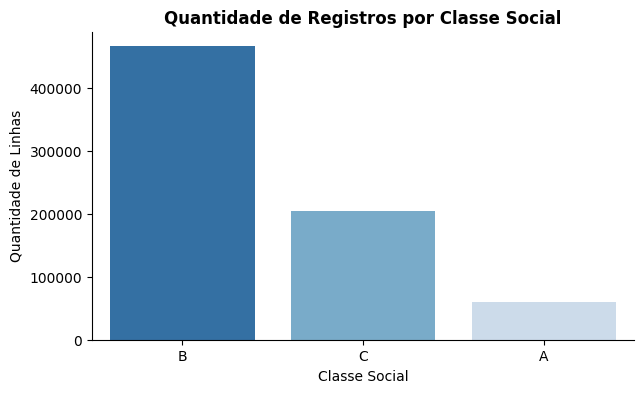

In [30]:
plt.figure(figsize=(7, 4))

ax = sns.countplot(x='cl_classe', data=df_limpo, palette='Blues_r', order=df_limpo['cl_classe'].value_counts().index)

sns.despine()
plt.title('Quantidade de Registros por Classe Social', fontsize=12, fontweight='bold')
plt.xlabel('Classe Social')
plt.ylabel('Quantidade de Linhas')
plt.show()